# Lab 2: Regression Analysis

## Aim
To implement and compare linear, multiple linear, and logistic regression models.

## Datasets Used

1. Linear Regression - Boston Housing Dataset
2. Multiple Linear Regression - Student Performance Dataset
3. Logistic Regression - Breast Cancer Dataset

## Objective

- Implement Linear Regression using mathematical formulas.
- Implement Multiple Linear Regression using mathematical formulas.
- Implement Logistic Regression using the sigmoid function and gradient descent.
- Evaluate regression models using MAE, RMSE and R² Score.
- Evaluate classification using Accuracy, Precision, Recall and F1 Score.
- Visualize the model results.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# PART A — LINEAR REGRESSION

Load Boston Housing data

In [3]:
housing = pd.read_csv("datasets/housing.csv")

In [4]:
housing.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [107]:
housing.shape

(506, 14)

In [108]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [109]:
housing.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [110]:
housing.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [111]:
x = housing[["rm"]].values.flatten()
y = housing["medv"].values

In [113]:
np.random.seed(42)

indices = np.random.permutation(len(x))
x = x[indices]
y = y[indices]

In [114]:
split = int(0.8 * len(x))

In [115]:
x_train = x[:split]
y_train = y[:split]

In [116]:
x_test = x[split:]
y_test = y[split:]

In [117]:
print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

Training samples: 404
Testing samples: 102


## Feature scaling
This is important because Gradient Descent works much better when values are reasonably scaled.

In [118]:
mean = x_train.mean(axis=0)
std = x_train.std(axis=0)

x_train_scaled = (x_train - mean) / std
x_test_scaled = (x_test - mean) / std

In [119]:
theta0 = 0
theta1 = 0

In [120]:
eta = 0.01

In [121]:
iterations = 1000

In [122]:
def predict_linear(x, theta0, theta1):
    return theta0 + theta1 * x

In [123]:
def compute_cost(x, y, theta0, theta1):
    m = len(y)

    predictions = predict_linear(x, theta0, theta1)

    error = predictions - y

    cost = (1 / (2 * m)) * np.sum(error ** 2)

    return cost

## Gradient Descent

In [124]:
def train_linear_regression(x,y,eta,iterations):
    m = len(y)
    
    theta0 = 0
    theta1 = 0
    
    cost_history = []
    
    for i in range(iterations):
        predictions = predict_linear(x, theta0, theta1)
        
        error = predictions - y
        
        d_theta0 = (1/m) * np.sum(error)
        d_theta1 = (1/m) * np.sum(error*x)
        
        theta0 = theta0 - eta*d_theta0
        theta1 = theta1 - eta*d_theta1
        
        cost = compute_cost(x,y,theta0,theta1)
        
        cost_history.append(cost)
        
    return theta0, theta1, cost_history

In [125]:
theta0, theta1, cost_history = train_linear_regression(
    x_train_scaled,
    y_train,
    eta,
    iterations
)

In [126]:
print("Theta 0:", theta0)
print("Theta 1:", theta1)

Theta 0: 22.498781132866736
Theta 1: 6.218008835000731


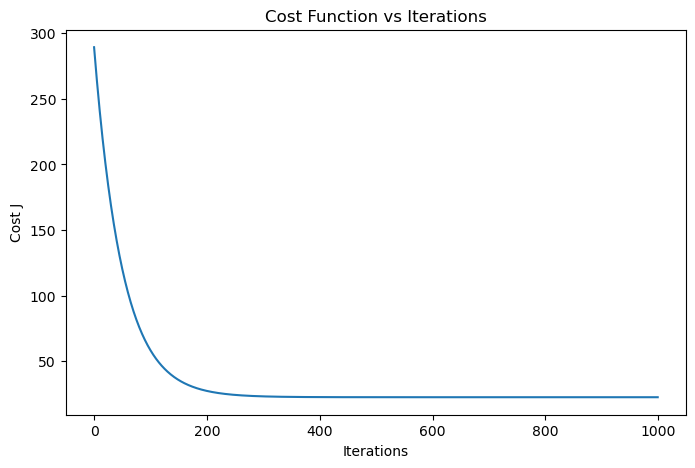

In [127]:
plt.figure(figsize=(8,5))

plt.plot(cost_history)

plt.xlabel("Iterations")
plt.ylabel("Cost J")
plt.title("Cost Function vs Iterations")

plt.show()

## Make Prediction

In [128]:
y_pred = predict_linear(
    x_test_scaled,
    theta0,
    theta1
)

In [129]:
print("Actual:", y_test[:10])
print("Predicted:", y_pred[:10])

Actual: [14.1 50.  34.9 19.8 23.7 20.2 13.5 23.2 38.7 15.3]
Predicted: [24.64660617 29.05442719 30.57157944 17.97652261 14.65494669 24.53887938
 19.35901638 20.39139809 38.50745274 11.06405379]


# MAE

In [130]:
mae = np.mean(np.abs(y_test - y_pred))

print("MAE:", mae)

MAE: 4.384128443879296


# RMSE

In [131]:
rmse = np.sqrt(
    np.mean((y_test - y_pred) ** 2)
)

print("RMSE:", rmse)

RMSE: 6.237610289214736


# R^2 Score

In [134]:
ss_res = np.sum((y_test - y_pred) ** 2)

ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)

r2 = 1 - (ss_res / ss_tot)

print("R^2 Score:", r2)

R^2 Score: 0.5587752919765483


# Visualization

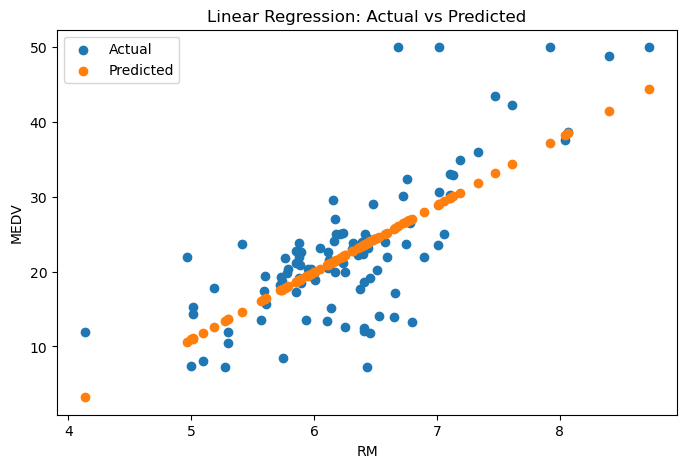

In [135]:
plt.figure(figsize=(8,5))

plt.scatter(x_test, y_test, label="Actual")
plt.scatter(x_test, y_pred, label="Predicted")

plt.xlabel("RM")
plt.ylabel("MEDV")
plt.title("Linear Regression: Actual vs Predicted")

plt.legend()
plt.show()

# Multiple Linear Regression

### Load Student Performance

In [7]:
student = pd.read_csv("datasets/student-mat.csv", sep=";")

In [8]:
student.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [9]:
student.shape

(395, 33)

In [10]:
student.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [11]:
student.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


### Select multiple features

In [12]:
features = [
    "studytime",
    "failures",
    "absences",
    "G1",
    "G2"
]

x = student[features].values
y = student["G3"].values

### Split data

In [13]:
np.random.seed(42)

indices = np.random.permutation(len(x))

x = x[indices]
y = y[indices]

split = int(0.8 * len(x))

x_train = x[:split]
x_test = x[split:]

y_train = y[:split]
y_test = y[split:]

### Scale

In [14]:
mean = x_train.mean(axis=0)
std = x_train.std(axis=0)

x_train_scaled = (x_train - mean) / std
x_test_scaled = (x_test - mean) / std

### Multiple regression prediction

In [15]:
def predict_multiple(x, theta):
    return x @ theta

In [16]:
x_train_b = np.c_[np.ones(x_train_scaled.shape[0]), x_train_scaled]

x_test_b = np.c_[np.ones(x_test_scaled.shape[0]), x_test_scaled]

Initialize

In [17]:
theta = np.zeros(x_train_b.shape[1])

eta = 0.01
iterations = 2000

### Multiple regression cost

In [18]:
def multiple_cost(x,y,theta):
    m = len(y)
    predictions = x @ theta # @ means dot
    error = predictions - y
    
    cost = (1/(2*m))*np.sum(error**2)
    
    return cost

### Multiple regression Gradient Descent

In [19]:
def train_multiple_regression(x,y,eta, iterations):
    m = len(y)
    
    theta = np.zeros(x.shape[1])
    
    cost_history = []
    
    for i in range(iterations):
        predictions = x @ theta
        error = predictions - y
        gradients = (1/m)*(x.T @ error)
        
        theta = theta - eta*gradients
        cost = multiple_cost(x,y,theta)
        cost_history.append(cost)
        
    return theta, cost_history

Train

In [20]:
theta, cost_history = train_multiple_regression(x_train_b, y_train,eta,iterations)

In [21]:
print("Parameters:", theta)

Parameters: [10.42405061 -0.06736185 -0.16471788  0.31895109  0.7202853   3.55077512]


### Predict

In [22]:
y_pred = x_test_b @ theta

In [23]:
mae = np.mean(np.abs(y_test - y_pred))

rmse = np.sqrt(np.mean((y_test - y_pred)**2))

ss_res = np.sum((y_test - y_pred)**2)

ss_tot = np.sum((y_test - np.mean(y_test))**2)

r2 = 1 - (ss_res / ss_tot)

print("MAE: ",mae)
print("RMSE: ", rmse)
print("R^2 Score: ", r2)

MAE:  1.1724946906462652
RMSE:  2.016887158305052
R^2 Score:  0.774105753349484


## Visualize

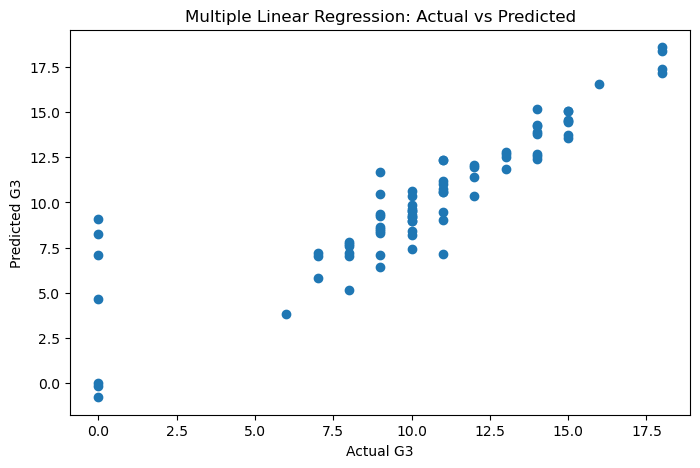

In [24]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Multiple Linear Regression: Actual vs Predicted")

plt.show()

# LOGISTIC REGRESSION

### Load the Breast Cancer dataset

In [25]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()



In [28]:
print(cancer)

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30)), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,

In [29]:
print("Feature names:")
print(cancer.feature_names)

print("\nTarget names:")
print(cancer.target_names)

print("\nData shape:")
print(cancer.data.shape)

print("\nTarget shape:")
print(cancer.target.shape)

Feature names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Target names:
['malignant' 'benign']

Data shape:
(569, 30)

Target shape:
(569,)


## Convert the dataset into a DataFrame

In [30]:
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)

df["target"] = cancer.target

print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [31]:
print(df.shape)

(569, 31)


In [32]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [33]:
print(df.describe())

       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   
25%      

## Check Missing value

In [34]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [35]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [36]:
X = cancer.data
y = cancer.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [37]:
print(cancer.target_names)

['malignant' 'benign']


In [38]:
print(np.bincount(y))

[212 357]


### Train-Test Split

In [40]:
np.random.seed(42)

indices = np.random.permutation(len(X))

train_size = int(0.8 * len(X))

train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X[train_indices]
X_test = X[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 455
Testing samples: 114


Feature Scaling

In [41]:
X_mean = np.mean(X_train, axis=0)
X_std = np.std(X_train, axis=0)

In [42]:
X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

In [43]:
X_train_b = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_b = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

In [44]:
print("Before adding 1:", X_train_scaled.shape)
print("After adding 1:", X_train_b.shape)

Before adding 1: (455, 30)
After adding 1: (455, 31)


In [45]:
theta = np.zeros(X_train_b.shape[1])

print("Number of theta values:", len(theta))
print(theta)

Number of theta values: 31
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0.]


### Sigmoid Function

In [46]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [47]:
print(sigmoid(0))
print(sigmoid(1))
print(sigmoid(-1))

0.5
0.7310585786300049
0.2689414213699951


### Hypothesis / Prediction Probability

In [48]:
z = np.dot(X_train_b, theta)

y_prob = sigmoid(z)

print(y_prob[:10])

[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]


### Logistic Regression Cost Function

In [49]:
def compute_cost(X, y, theta):

    m = len(y)

    z = np.dot(X, theta)

    h = sigmoid(z)

    epsilon = 1e-15

    h = np.clip(h, epsilon, 1 - epsilon)

    cost = -(1/m) * np.sum(
        y * np.log(h) +
        (1-y) * np.log(1-h)
    )

    return cost

Gradient Descent

In [50]:
eta = 0.01
iterations = 5000

m = len(y_train)

cost_history = []

for i in range(iterations):

    # Prediction
    z = np.dot(X_train_b, theta)
    h = sigmoid(z)

    # Error
    error = h - y_train

    # Gradient
    gradient = (1/m) * np.dot(X_train_b.T, error)

    # Update theta
    theta = theta - eta * gradient

    # Calculate cost
    cost = compute_cost(X_train_b, y_train, theta)

    cost_history.append(cost)

print("Training completed.")

print("Final Cost:", cost_history[-1])
print("Theta:")
print(theta)

Training completed.
Final Cost: 0.05982748513013188
Theta:
[ 0.52346984 -0.52089312 -0.56292452 -0.50782193 -0.55221437 -0.33357954
 -0.08618375 -0.44436827 -0.5753317  -0.09384088  0.27137091 -0.68089048
  0.00878607 -0.51257854 -0.65944209 -0.0215954   0.36556076  0.14810598
 -0.09803992  0.19866801  0.34123961 -0.71001982 -0.78335234 -0.66141056
 -0.69904695 -0.58759848 -0.23133696 -0.47632694 -0.64109496 -0.48378604
 -0.18076444]


Visualize Cost vs Iterations

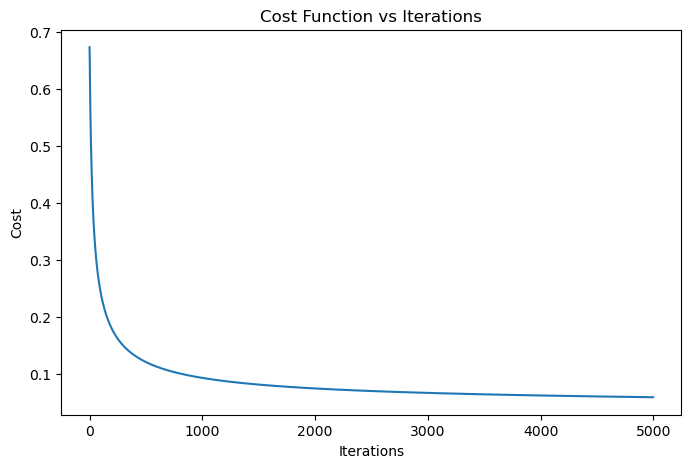

In [51]:
plt.figure(figsize=(8, 5))

plt.plot(cost_history)

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Function vs Iterations")

plt.show()

Prediction Probability on Test Data

In [52]:
test_z = np.dot(X_test_b, theta)

y_test_prob = sigmoid(test_z)

print(y_test_prob[:10])

[1.98003047e-04 4.09192380e-04 9.98636556e-01 6.22081667e-04
 4.36961967e-06 9.94775850e-01 9.98795435e-01 9.99350102e-01
 2.42103763e-07 9.99884302e-01]


In [53]:
y_pred = (y_test_prob >= 0.5).astype(int)

print("Predicted:", y_pred[:20])
print("Actual:   ", y_test[:20])

Predicted: [0 0 1 0 0 1 1 1 0 1 0 0 0 1 1 1 0 1 1 0]
Actual:    [0 0 1 0 0 1 1 1 0 1 0 0 0 0 1 1 0 1 1 0]


### Confusion Matrix

In [54]:
TP = np.sum((y_test == 1) & (y_pred == 1))
TN = np.sum((y_test == 0) & (y_pred == 0))
FP = np.sum((y_test == 0) & (y_pred == 1))
FN = np.sum((y_test == 1) & (y_pred == 0))

print("True Positive :", TP)
print("True Negative :", TN)
print("False Positive:", FP)
print("False Negative:", FN)

True Positive : 66
True Negative : 44
False Positive: 3
False Negative: 1


Accuracy

In [55]:
accuracy = (TP + TN) / (TP + TN + FP + FN)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.9649122807017544
Accuracy (%): 96.49122807017544


Precision

In [56]:
precision = TP / (TP + FP)

print("Precision:", precision)

Precision: 0.9565217391304348


Recall

In [57]:
recall = TP / (TP + FN)

print("Recall:", recall)

Recall: 0.9850746268656716


F1 Score

In [58]:
f1 = 2 * (precision * recall) / (precision + recall)

print("F1 Score:", f1)

F1 Score: 0.9705882352941176


In [59]:
print(" Logistic Regression Results")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

 Logistic Regression Results
Accuracy : 0.9649122807017544
Precision: 0.9565217391304348
Recall   : 0.9850746268656716
F1 Score : 0.9705882352941176


Visualize Confusion Matrix

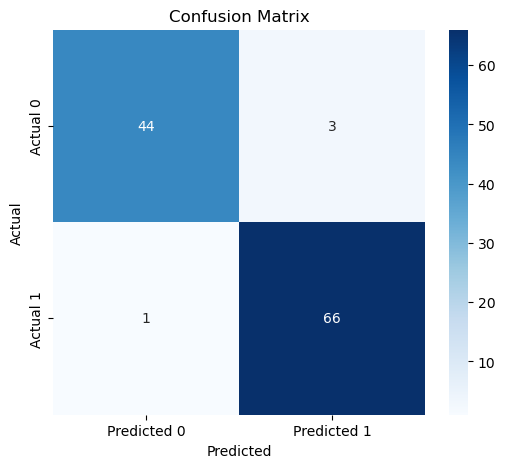

In [60]:
confusion_matrix = np.array([
    [TN, FP],
    [FN, TP]
])

plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Visualize Class Distribution

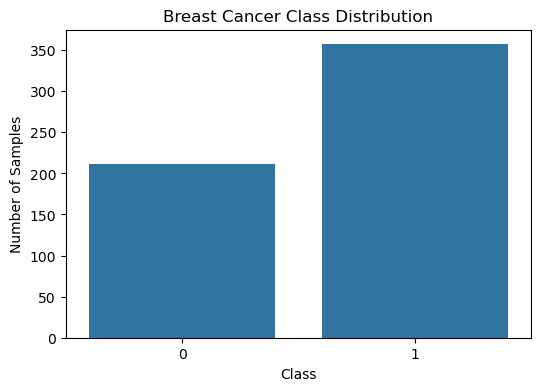

In [61]:
plt.figure(figsize=(6, 4))

sns.countplot(x=y)

plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Breast Cancer Class Distribution")

plt.show()

Visualization of two features

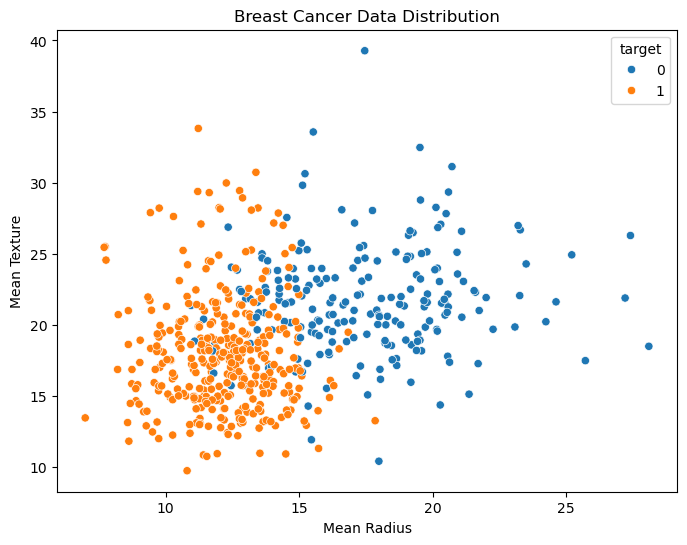

In [62]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=df["mean radius"],
    y=df["mean texture"],
    hue=df["target"]
)

plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("Breast Cancer Data Distribution")

plt.show()